# Dynamic Barrier Coverage | Mobile Sensors with Charging Docks

**Adnan Ejaz**

---
## Cell 1 — Install & Import Libraries

In [ ]:
# All libraries below come pre-installed in Google Colab — no pip install needed

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
from scipy.ndimage import gaussian_filter

np.random.seed(42)
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## Cell 2 — Parameters

In [ ]:
# ══════════════════════════════════════════════
#  PARAMETERS  —  change these freely
# ══════════════════════════════════════════════

DOMAIN_KM    = 10      # domain is [-DOMAIN_KM, DOMAIN_KM] in both axes
M            = 5       # number of sensors  (same as original paper)
RHO          = 0.95    # max detection probability
SIGMA_L      = 2.5     # sensor detection length-scale (km)
ROAM_RADIUS  = 3.0     # max roaming distance from dock (km)
SLEEP_THRESH = 0.80    # VP threshold below which sensor cannot sleep
ALPHA_LEARN  = 0.30    # learning rate (exponential moving average)
N_LEARN_DAYS = 30      # days to simulate in the learning experiment

# ── Representation space grid ──────────────────
# alpha = angle of ship trajectory (0 to pi)
# p     = shortest distance from trajectory to origin
alpha_vals = np.deg2rad(np.linspace(2.5, 177.5, 36))   # 36 angle bins
p_vals     = np.linspace(-DOMAIN_KM, DOMAIN_KM, 41)    # 41 distance bins
ALPHA, P   = np.meshgrid(alpha_vals, p_vals)            # shape (41, 36)
DA = alpha_vals[1] - alpha_vals[0]   # angle step size
DP = p_vals[1]     - p_vals[0]       # distance step size

# ── Candidate sensor positions (fine grid) ─────
xs_c = np.linspace(-DOMAIN_KM, DOMAIN_KM, 21)   # 21 x 21 = 441 candidates
ys_c = np.linspace(-DOMAIN_KM, DOMAIN_KM, 21)
XX_c, YY_c = np.meshgrid(xs_c, ys_c)
CANDS = np.column_stack([XX_c.ravel(), YY_c.ravel()])

print(f'✅ Parameters set')
print(f'   Domain        : [{-DOMAIN_KM}, {DOMAIN_KM}] km × [{-DOMAIN_KM}, {DOMAIN_KM}] km')
print(f'   Sensors M     : {M}')
print(f'   Roam radius   : {ROAM_RADIUS} km')
print(f'   Candidates    : {len(CANDS)} positions')
print(f'   Rep-space grid: {ALPHA.shape[0]} p-bins × {ALPHA.shape[1]} alpha-bins')

✅ Parameters set
   Domain        : [-10, 10] km × [-10, 10] km
   Sensors M     : 5
   Roam radius   : 3.0 km
   Candidates    : 441 positions
   Rep-space grid: 41 p-bins × 36 alpha-bins


---
## Cell 3 — Traffic Intensity Heatmaps

Each time window has its own intensity function **λₖ(α, p)** in the representation space.

- **Morning**: cargo ships & tankers → concentrated north-south channel → tight cluster near α ≈ 90°
- **Evening**: ferries & fishing boats → diagonal routes → spread clusters at α ≈ 58° and α ≈ 122°
- **Night**: very sparse traffic → 15% of combined morning+evening
- **Transition**: blend of morning and evening (12:00–15:00)

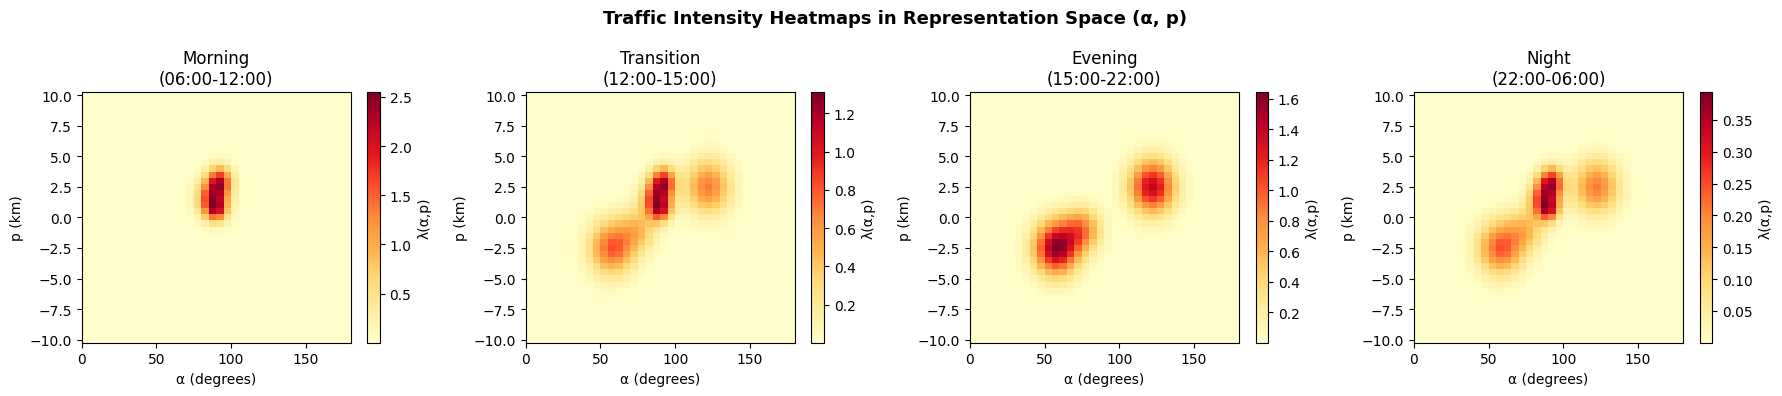

✅ Intensity heatmaps created


In [ ]:
def gauss_peak(a_centre, p_centre, sigma_a, sigma_p, amplitude=1.0):
    """
    Create a single Gaussian peak in representation space (alpha, p).
    Used to simulate a cluster of ship trajectories.

    Parameters
    ----------
    a_centre  : float  — centre angle in radians
    p_centre  : float  — centre p-distance in km
    sigma_a   : float  — spread in angle direction (radians)
    sigma_p   : float  — spread in p direction (km)
    amplitude : float  — peak height (traffic density)
    """
    return amplitude * np.exp(
        -0.5 * ((ALPHA - a_centre) / sigma_a)**2
        -0.5 * ((P     - p_centre) / sigma_p)**2
    )

# ── MORNING: heavy cargo ships in a narrow north-south channel ──────
# Three overlapping peaks near alpha = 88-92 degrees, p = 0.5-3.0 km
lam_morning = (
    gauss_peak(np.deg2rad(88), 1.5, 0.12, 1.0, amplitude=2.0)
  + gauss_peak(np.deg2rad(92), 3.0, 0.10, 0.8, amplitude=1.8)
  + gauss_peak(np.deg2rad(90), 0.5, 0.08, 0.6, amplitude=1.2)
)
lam_morning = np.maximum(lam_morning, 1e-6)   # ensure non-negative

# ── EVENING: ferries and fishing boats on diagonal routes ───────────
# Peaks at alpha = 58 degrees (SW-NE) and alpha = 122 degrees (NW-SE)
lam_evening = (
    gauss_peak(np.deg2rad(58),  -2.5, 0.18, 1.5, amplitude=1.6)
  + gauss_peak(np.deg2rad(122),  2.5, 0.18, 1.5, amplitude=1.4)
  + gauss_peak(np.deg2rad(75),  -1.0, 0.15, 1.2, amplitude=0.8)
)
lam_evening = np.maximum(lam_evening, 1e-6)

# ── NIGHT: very sparse traffic ──────────────────────────────────────
lam_night = 0.15 * (lam_morning + lam_evening)
lam_night  = np.maximum(lam_night, 1e-6)

# ── TRANSITION: blend of morning and evening (12:00–15:00) ─────────
lam_transition = 0.5 * lam_morning + 0.5 * lam_evening
lam_transition = np.maximum(lam_transition, 1e-6)

# ── AVERAGE: what the original paper uses (time-weighted blend) ─────
lam_average = (
    0.30 * lam_morning
  + 0.30 * lam_evening
  + 0.25 * lam_night
  + 0.15 * lam_transition
)
lam_average = np.maximum(lam_average, 1e-6)

# ── Package all windows into a dictionary for easy access ──────────
TIME_WINDOWS = {
    'Morning'   : {'lam': lam_morning,    'weight': 0.30, 'color': '#F4A460', 'hours': '06:00-12:00'},
    'Transition': {'lam': lam_transition, 'weight': 0.15, 'color': '#DDA0DD', 'hours': '12:00-15:00'},
    'Evening'   : {'lam': lam_evening,    'weight': 0.30, 'color': '#6495ED', 'hours': '15:00-22:00'},
    'Night'     : {'lam': lam_night,      'weight': 0.25, 'color': '#2F4F4F', 'hours': '22:00-06:00'},
}

# ── Quick visualisation of all four intensity maps ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Traffic Intensity Heatmaps in Representation Space (α, p)',
             fontsize=13, fontweight='bold')

for ax, (name, info) in zip(axes, TIME_WINDOWS.items()):
    c = ax.pcolormesh(np.rad2deg(alpha_vals), p_vals, info['lam'],
                      cmap='YlOrRd', shading='auto')
    plt.colorbar(c, ax=ax, label='λ(α,p)')
    ax.set_xlabel('α (degrees)')
    ax.set_ylabel('p (km)')
    ax.set_title(f'{name}\n({info["hours"]})')

plt.tight_layout()
plt.show()
print('✅ Intensity heatmaps created')

---
## Cell 4 — Sensor Model & Void Probability

**Detection probability** of a trajectory (α, p) by a sensor at position (ax, ay):
$$\gamma_\mathcal{C}(l, a_i) = \rho \cdot \exp\left(-\frac{d^2}{\sigma_l}\right)$$
where $d = |a_x \sin(\alpha) - a_y \cos(\alpha) - p|$ is the minimum distance from sensor to trajectory.

**Void probability** (probability ALL ships are detected):
$$\nu(\mathbf{a}) = \exp\left(-\int_\Theta E[\lambda(l)] \cdot \pi_\mathcal{C}(l, \mathbf{a})\, dl\right)$$

In [ ]:
def gamma_C(alpha, p, ax, ay):
    """
    Detection probability of trajectory (alpha, p) by sensor at (ax, ay).

    Uses the minimum distance from the sensor to the line trajectory
    (standard normal-form line distance formula).

    Returns array of same shape as alpha and p.
    """
    # Minimum distance from point (ax, ay) to line: x*sin(a) - y*cos(a) = p
    dist = np.abs(ax * np.sin(alpha) - ay * np.cos(alpha) - p)
    return RHO * np.exp(-(dist**2) / SIGMA_L)


def void_prob(sensors, lam):
    """
    Compute the void probability approximation (Jensen lower bound)
    for a given set of sensor positions and intensity function.

    VP = exp( -integral of lambda(l) * pi_C(l, sensors) dl )

    Parameters
    ----------
    sensors : list of [x, y] positions
    lam     : 2D numpy array of intensity values (shape = ALPHA.shape)

    Returns
    -------
    float in [0, 1] — higher is better (1 = perfect detection)
    """
    if len(sensors) == 0:
        return 0.0

    # Start with probability 1 = all sensors miss
    # Multiply miss probabilities across all sensors
    fail = np.ones_like(lam, dtype=float)
    for (ax, ay) in sensors:
        fail *= (1.0 - gamma_C(ALPHA, P, ax, ay))

    # Integrate miss probability weighted by intensity
    # = expected number of undetected trajectories
    integral = np.sum(lam * fail) * DA * DP

    return float(np.exp(-integral))


# ── Quick sanity check ──────────────────────────────────────────────
test_sensor = [[0.0, 0.0]]   # single sensor at origin
vp_test = void_prob(test_sensor, lam_morning)
print(f'✅ Sensor model ready')
print(f'   Test: 1 sensor at origin → morning VP = {vp_test:.4f}')
print(f'   (Expected: small but non-zero — one sensor cannot cover everything)')

✅ Sensor model ready
   Test: 1 sensor at origin → morning VP = 0.1683
   (Expected: small but non-zero — one sensor cannot cover everything)


---
## Cell 5 — STEP 1: Original Paper Greedy → Dock Positions

This reproduces the original paper's greedy algorithm on the **time-averaged** intensity.

The M positions found here become **charging dock locations** — permanent infrastructure.

> **Greedy rule**: at each step, add the sensor that maximises the void probability given sensors already placed.

Running original paper greedy algorithm on time-averaged intensity...
(These positions become charging dock locations)

   Sensor 1 placed at (+1.0, +4.0) km  →  VP = 0.1671
   Sensor 2 placed at (-1.0, +4.0) km  →  VP = 0.3455
   Sensor 3 placed at (+3.0, +4.0) km  →  VP = 0.5966
   Sensor 4 placed at (-3.0, +4.0) km  →  VP = 0.7333
   Sensor 5 placed at (+2.0, +7.0) km  →  VP = 0.8228

Dock positions (charging station locations):
   Dock 1: (+1.0, +4.0) km
   Dock 2: (-1.0, +4.0) km
   Dock 3: (+3.0, +4.0) km
   Dock 4: (-3.0, +4.0) km
   Dock 5: (+2.0, +7.0) km

Void probability at dock positions per window (sensors stay at docks, no roaming):
   Morning     : VP = 0.8515
   Transition  : VP = 0.7895
   Evening     : VP = 0.7320
   Night       : VP = 0.9315


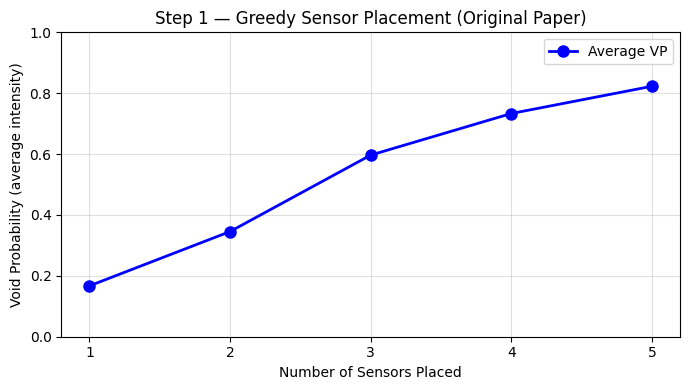

✅ Dock positions found


In [ ]:
def greedy_static(n_sensors, lam, candidates=None):
    """
    Original paper greedy algorithm.
    Places n_sensors one at a time, each time choosing the candidate
    position that maximally increases the void probability.

    Parameters
    ----------
    n_sensors  : int    — number of sensors to place
    lam        : array  — intensity function to optimise against
    candidates : array  — (N, 2) candidate positions

    Returns
    -------
    selected   : list of [x, y] sensor positions
    vp_history : list of void probability after each sensor added
    """
    if candidates is None:
        candidates = CANDS

    selected   = []
    vp_history = []

    for step in range(n_sensors):
        best_vp  = -1.0
        best_pos = None

        for pos in candidates:
            vp = void_prob(selected + [list(pos)], lam)
            if vp > best_vp:
                best_vp  = vp
                best_pos = list(pos)

        selected.append(best_pos)
        vp_history.append(best_vp)
        print(f'   Sensor {step+1} placed at ({best_pos[0]:+.1f}, {best_pos[1]:+.1f}) km  '
              f'→  VP = {best_vp:.4f}')

    return selected, vp_history


# ── Run original paper greedy on time-averaged intensity ────────────
print('Running original paper greedy algorithm on time-averaged intensity...')
print(f'(These positions become charging dock locations)')
print()

dock_positions, dock_vp_history = greedy_static(M, lam_average)

print()
print('Dock positions (charging station locations):')
for i, d in enumerate(dock_positions):
    print(f'   Dock {i+1}: ({d[0]:+.1f}, {d[1]:+.1f}) km')

print()
print('Void probability at dock positions per window (sensors stay at docks, no roaming):')
vp_at_dock = {}
for name, info in TIME_WINDOWS.items():
    vp = void_prob(dock_positions, info['lam'])
    vp_at_dock[name] = vp
    print(f'   {name:12s}: VP = {vp:.4f}')

# ── Plot VP build-up as sensors are added ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, M+1), dock_vp_history, 'b-o', lw=2, ms=8, label='Average VP')
ax.set_xlabel('Number of Sensors Placed')
ax.set_ylabel('Void Probability (average intensity)')
ax.set_title('Step 1 — Greedy Sensor Placement (Original Paper)')
ax.set_xticks(range(1, M+1))
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()
print('✅ Dock positions found')

---
## Cell 6 — STEP 2: Roaming Deployment per Time Window

For each time window, each sensor roams from its dock to the **best reachable position** within radius `ROAM_RADIUS`.

$$F_{ik} = \{x \in A : \|x - d_i\|_2 \leq R_i\}$$

Greedy selection is applied within each sensor's feasible region $F_{ik}$.

In [ ]:
def get_feasible_candidates(dock_pos, roam_radius, candidates=None):
    """
    Return candidate positions within roaming radius of dock.

    Parameters
    ----------
    dock_pos    : [x, y] — dock position
    roam_radius : float  — max roaming distance in km

    Returns
    -------
    List of [x, y] positions within radius
    """
    if candidates is None:
        candidates = CANDS
    dists = np.sqrt((candidates[:, 0] - dock_pos[0])**2 +
                    (candidates[:, 1] - dock_pos[1])**2)
    return candidates[dists <= roam_radius].tolist()


def greedy_roaming(n_sensors, dock_positions, lam, roam_radius):
    """
    Greedy sensor placement where each sensor i can only be placed
    within roam_radius of its home dock dock_positions[i].

    Sensors are assigned in order 1, 2, ..., M.
    Each sensor greedily picks the best feasible position given
    the sensors already placed before it.

    Parameters
    ----------
    n_sensors      : int   — number of sensors
    dock_positions : list  — list of [x, y] dock positions
    lam            : array — intensity for this time window
    roam_radius    : float — max roaming distance from dock

    Returns
    -------
    selected     : list of deployed [x, y] positions
    deploy_info  : list of dicts with deployment details per sensor
    """
    selected    = []
    deploy_info = []

    for i in range(n_sensors):
        dock     = dock_positions[i]
        feasible = get_feasible_candidates(dock, roam_radius)

        if len(feasible) == 0:
            # No candidate within radius — stay at dock
            selected.append(dock)
            deploy_info.append({
                'sensor': i+1, 'dock': dock, 'deployed': dock,
                'distance': 0.0, 'status': 'AT DOCK (no feasible candidate)'
            })
            continue

        # Greedy: pick feasible position that maximises VP given already-placed sensors
        best_vp, best_pos = -1.0, None
        for pos in feasible:
            vp = void_prob(selected + [pos], lam)
            if vp > best_vp:
                best_vp, best_pos = vp, pos

        dist = np.sqrt((best_pos[0] - dock[0])**2 + (best_pos[1] - dock[1])**2)
        selected.append(best_pos)
        deploy_info.append({
            'sensor': i+1, 'dock': dock, 'deployed': best_pos,
            'distance': dist,
            'status': f'AT DOCK' if dist < 0.01 else f'roamed {dist:.2f} km'
        })

    return selected, deploy_info


# ── Run roaming deployment for all time windows ─────────────────────
print('Running roaming deployment for each time window...')
print()

results = {}
for name, info in TIME_WINDOWS.items():
    sensors, dep_info = greedy_roaming(M, dock_positions, info['lam'], ROAM_RADIUS)
    vp_roam = void_prob(sensors, info['lam'])
    vp_dock = vp_at_dock[name]   # sensors stay at docks — from Cell 5
    improvement = (vp_roam - vp_dock) / max(vp_dock, 1e-9) * 100

    results[name] = {
        'lam'        : info['lam'],
        'color'      : info['color'],
        'weight'     : info['weight'],
        'sensors'    : sensors,
        'dep_info'   : dep_info,
        'vp_roam'    : vp_roam,
        'vp_dock'    : vp_dock,
        'improvement': improvement,
    }

    print(f'{name:12s}:')
    print(f'   VP at docks  = {vp_dock:.4f}')
    print(f'   VP w/ roaming= {vp_roam:.4f}  ({improvement:+.2f}%)')
    for d in dep_info:
        print(f'   Sensor {d["sensor"]}: dock({d["dock"][0]:+.1f},{d["dock"][1]:+.1f}) '
              f'→ deploy({d["deployed"][0]:+.1f},{d["deployed"][1]:+.1f})  [{d["status"]}]')
    print()

print('✅ Roaming deployment computed for all windows')

Running roaming deployment for each time window...

Morning     :
   VP at docks  = 0.8515
   VP w/ roaming= 0.9531  (+11.93%)
   Sensor 1: dock(+1.0,+4.0) → deploy(+2.0,+2.0)  [roamed 2.24 km]
   Sensor 2: dock(-1.0,+4.0) → deploy(+1.0,+2.0)  [roamed 2.83 km]
   Sensor 3: dock(+3.0,+4.0) → deploy(+3.0,+1.0)  [roamed 3.00 km]
   Sensor 4: dock(-3.0,+4.0) → deploy(+0.0,+4.0)  [roamed 3.00 km]
   Sensor 5: dock(+2.0,+7.0) → deploy(+4.0,+5.0)  [roamed 2.83 km]

Transition  :
   VP at docks  = 0.7895
   VP w/ roaming= 0.7895  (+0.00%)
   Sensor 1: dock(+1.0,+4.0) → deploy(+1.0,+4.0)  [AT DOCK]
   Sensor 2: dock(-1.0,+4.0) → deploy(-1.0,+4.0)  [AT DOCK]
   Sensor 3: dock(+3.0,+4.0) → deploy(+3.0,+4.0)  [AT DOCK]
   Sensor 4: dock(-3.0,+4.0) → deploy(-3.0,+4.0)  [AT DOCK]
   Sensor 5: dock(+2.0,+7.0) → deploy(+2.0,+7.0)  [AT DOCK]

Evening     :
   VP at docks  = 0.7320
   VP w/ roaming= 0.7314  (-0.07%)
   Sensor 1: dock(+1.0,+4.0) → deploy(+0.0,+4.0)  [roamed 1.00 km]
   Sensor 2: dock(-1.

---
## Cell 7 — STEP 3: Sleep Scheduling

**Rule**: If removing sensor $i$ from the active set keeps void probability above threshold $\theta$, sensor $i$ sleeps (returns to dock to recharge).

$$\text{sensor } i \text{ sleeps} \iff \nu_k(\hat{\mathbf{a}}_k \setminus \{a_{ik}\}) \geq \theta$$

Sensors are removed greedily (least impactful first) until no more can be removed without dropping VP below $\theta$.

In [ ]:
def sleep_schedule(sensors, lam, threshold=SLEEP_THRESH):
    """
    Greedily put sensors to sleep if void probability stays
    above 'threshold' without them.

    Parameters
    ----------
    sensors   : list of [x, y] positions (already roaming-deployed)
    lam       : intensity function for this time window
    threshold : float — minimum acceptable void probability

    Returns
    -------
    active_idx   : list of sensor indices that stay active
    sleeping_idx : list of sensor indices that go to sleep
    vp_final     : void probability with only active sensors
    """
    active   = list(range(len(sensors)))
    sleeping = []

    # Keep trying to remove sensors as long as VP stays above threshold
    improved = True
    while improved and len(active) > 1:
        improved = False
        for i in active:
            remaining    = [sensors[j] for j in active if j != i]
            vp_without_i = void_prob(remaining, lam)
            if vp_without_i >= threshold:
                # Safe to put sensor i to sleep
                active.remove(i)
                sleeping.append(i)
                improved = True
                break    # restart the check after each removal

    vp_final = void_prob([sensors[i] for i in active], lam)
    return active, sleeping, vp_final


# ── Run sleep scheduling for all windows ────────────────────────────
print(f'Running sleep scheduling (threshold VP = {SLEEP_THRESH})...')
print()

for name in TIME_WINDOWS:
    sensors   = results[name]['sensors']
    lam       = results[name]['lam']

    active_idx, sleep_idx, vp_sleep = sleep_schedule(sensors, lam)
    active_sensors = [sensors[i] for i in active_idx]

    results[name]['active_idx']     = active_idx
    results[name]['sleep_idx']      = sleep_idx
    results[name]['active_sensors'] = active_sensors
    results[name]['vp_sleep']       = vp_sleep
    results[name]['n_sleeping']     = len(sleep_idx)

    power_saved = len(sleep_idx) / M * 100
    print(f'{name:12s}: {M - len(sleep_idx)} active, {len(sleep_idx)} sleeping  '
          f'VP = {vp_sleep:.4f}  ({power_saved:.0f}% power saved)')
    if sleep_idx:
        sleeping_labels = [f'Sensor {i+1}' for i in sleep_idx]
        print(f'   Sleeping: {sleeping_labels}')

total_sleep_events = sum(results[n]['n_sleeping'] for n in TIME_WINDOWS)
total_sensor_windows = M * len(TIME_WINDOWS)
print(f'\n   Overall sleep rate: {total_sleep_events}/{total_sensor_windows} sensor-windows '
      f'= {total_sleep_events/total_sensor_windows*100:.1f}% of all sensor-window combinations')
print('✅ Sleep scheduling complete')

Running sleep scheduling (threshold VP = 0.8)...

Morning     : 4 active, 1 sleeping  VP = 0.8865  (20% power saved)
   Sleeping: ['Sensor 1']
Transition  : 5 active, 0 sleeping  VP = 0.7895  (0% power saved)
Evening     : 5 active, 0 sleeping  VP = 0.7314  (0% power saved)
Night       : 4 active, 1 sleeping  VP = 0.8394  (20% power saved)
   Sleeping: ['Sensor 1']

   Overall sleep rate: 2/20 sensor-windows = 10.0% of all sensor-window combinations
✅ Sleep scheduling complete


---
## Cell 8 — STEP 4: Continuous Learning Simulation

The system updates its intensity estimate each day using an **exponential moving average**:

$$\lambda_k(l,\, t) = (1 - \alpha) \cdot \lambda_k(l,\, t-1) + \alpha \cdot \tilde{\lambda}_k(l,\, t)$$

- Day 1: estimate is noisy (limited data)
- Day 30: estimate closely matches true traffic pattern
- We measure void probability using the **true** intensity at each day

Simulating 30 days of continuous learning...

Morning  — Day 1: 0.9543  →  Day 30: 0.9531  (static baseline: 0.8515)
Evening  — Day 1: 0.7314  →  Day 30: 0.7260  (static baseline: 0.7320)


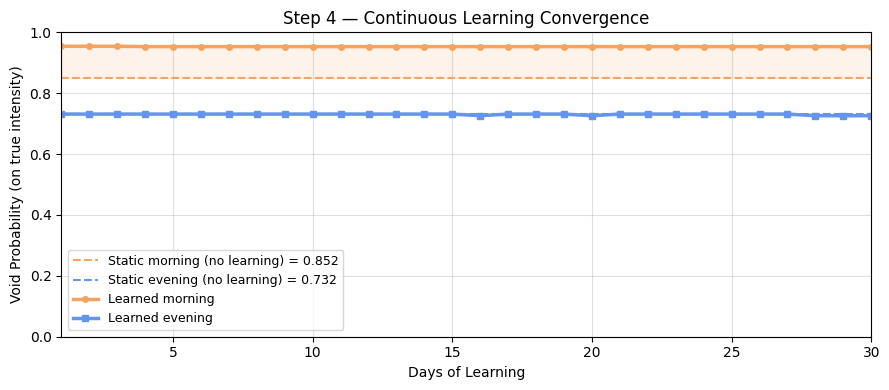

✅ Learning simulation complete


In [ ]:
def simulate_learning(true_lam, n_days=N_LEARN_DAYS, alpha=ALPHA_LEARN):
    """
    Simulate the continuous learning process over n_days.

    Each day:
    1. A new noisy observation of the intensity arrives
    2. The estimate is updated via exponential moving average
    3. Sensors are roaming-deployed based on the ESTIMATED intensity
    4. Void probability is evaluated on the TRUE intensity

    This simulates how well the system performs as it learns over time.

    Parameters
    ----------
    true_lam : 2D array — the true (unknown) intensity
    n_days   : int      — number of days to simulate
    alpha    : float    — learning rate

    Returns
    -------
    history : list of dicts with keys: day, estimated_lam, vp_on_true
    """
    # Day 0 estimate: very noisy — system just started
    # Multiply true intensity by random factors between 0.5 and 1.5
    initial_noise = np.random.uniform(0.5, 1.5, true_lam.shape)
    lam_estimate  = np.maximum(true_lam * initial_noise, 1e-6)

    history = []

    for day in range(1, n_days + 1):
        # New daily observation: true intensity + 15% noise
        daily_noise = np.random.uniform(0.85, 1.15, true_lam.shape)
        new_obs     = np.maximum(true_lam * daily_noise, 1e-6)

        # Exponential moving average update
        lam_estimate = (1 - alpha) * lam_estimate + alpha * new_obs
        lam_estimate = np.maximum(lam_estimate, 1e-6)

        # Deploy sensors using the ESTIMATED intensity (with roaming)
        sensors_from_estimate, _ = greedy_roaming(
            M, dock_positions, lam_estimate, ROAM_RADIUS
        )

        # Measure performance against the TRUE intensity
        vp_on_true = void_prob(sensors_from_estimate, true_lam)

        history.append({
            'day'           : day,
            'estimated_lam' : lam_estimate.copy(),
            'vp_on_true'    : vp_on_true,
        })

    return history


# ── Run learning simulation for morning and evening ──────────────────
print(f'Simulating {N_LEARN_DAYS} days of continuous learning...')
print()

learn_morning = simulate_learning(lam_morning)
learn_evening = simulate_learning(lam_evening)

# Static baseline: sensors always at docks, no learning benefit
vp_static_morning = results['Morning']['vp_dock']
vp_static_evening = results['Evening']['vp_dock']

days     = [h['day'] for h in learn_morning]
vp_m_all = [h['vp_on_true'] for h in learn_morning]
vp_e_all = [h['vp_on_true'] for h in learn_evening]

print(f'Morning  — Day 1: {vp_m_all[0]:.4f}  →  Day {N_LEARN_DAYS}: {vp_m_all[-1]:.4f}  '
      f'(static baseline: {vp_static_morning:.4f})')
print(f'Evening  — Day 1: {vp_e_all[0]:.4f}  →  Day {N_LEARN_DAYS}: {vp_e_all[-1]:.4f}  '
      f'(static baseline: {vp_static_evening:.4f})')

# Quick plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(vp_static_morning, color='#F4A460', ls='--', lw=1.5,
           label=f'Static morning (no learning) = {vp_static_morning:.3f}')
ax.axhline(vp_static_evening, color='#6495ED', ls='--', lw=1.5,
           label=f'Static evening (no learning) = {vp_static_evening:.3f}')
ax.plot(days, vp_m_all, color='#F4A460', lw=2.5, marker='o', ms=4, label='Learned morning')
ax.plot(days, vp_e_all, color='#6495ED', lw=2.5, marker='s', ms=4, label='Learned evening')
ax.fill_between(days, vp_static_morning, vp_m_all, color='#F4A460', alpha=0.12)
ax.fill_between(days, vp_static_evening, vp_e_all, color='#6495ED', alpha=0.12)
ax.set_xlabel('Days of Learning')
ax.set_ylabel('Void Probability (on true intensity)')
ax.set_title('Step 4 — Continuous Learning Convergence')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_xlim(1, N_LEARN_DAYS)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print('✅ Learning simulation complete')

---
## Cell 9 — STEP 5: Roaming Radius Sensitivity Analysis

How much does the void probability improve as we allow sensors to roam further?

Tests radii from 0.5 km (barely moves) up to 8.0 km (wide roaming).

Running roaming radius sensitivity analysis...
   Radius = 0.5 km  done
   Radius = 1.0 km  done
   Radius = 1.5 km  done
   Radius = 2.0 km  done
   Radius = 2.5 km  done
   Radius = 3.0 km  done
   Radius = 4.0 km  done
   Radius = 5.0 km  done
   Radius = 6.0 km  done
   Radius = 8.0 km  done


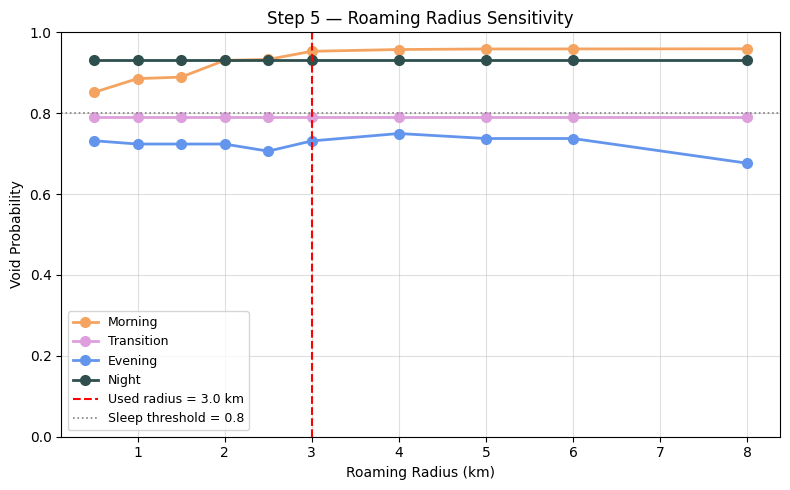

✅ Sensitivity analysis complete


In [ ]:
# ── Sweep roaming radius from 0.5 to 8.0 km ─────────────────────────
radii         = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0]
radius_vp     = {name: [] for name in TIME_WINDOWS}

print('Running roaming radius sensitivity analysis...')
for r in radii:
    for name, info in TIME_WINDOWS.items():
        sensors, _ = greedy_roaming(M, dock_positions, info['lam'], r)
        radius_vp[name].append(void_prob(sensors, info['lam']))
    print(f'   Radius = {r:.1f} km  done')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for name, info in TIME_WINDOWS.items():
    ax.plot(radii, radius_vp[name], 'o-', color=info['color'],
            lw=2, ms=7, label=name)

ax.axvline(ROAM_RADIUS, color='red', ls='--', lw=1.5,
           label=f'Used radius = {ROAM_RADIUS} km')
ax.axhline(SLEEP_THRESH, color='gray', ls=':', lw=1.2,
           label=f'Sleep threshold = {SLEEP_THRESH}')
ax.set_xlabel('Roaming Radius (km)')
ax.set_ylabel('Void Probability')
ax.set_title('Step 5 — Roaming Radius Sensitivity')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print('✅ Sensitivity analysis complete')

---
## Cell 10 — Figure 1: Main Results (6 panels)

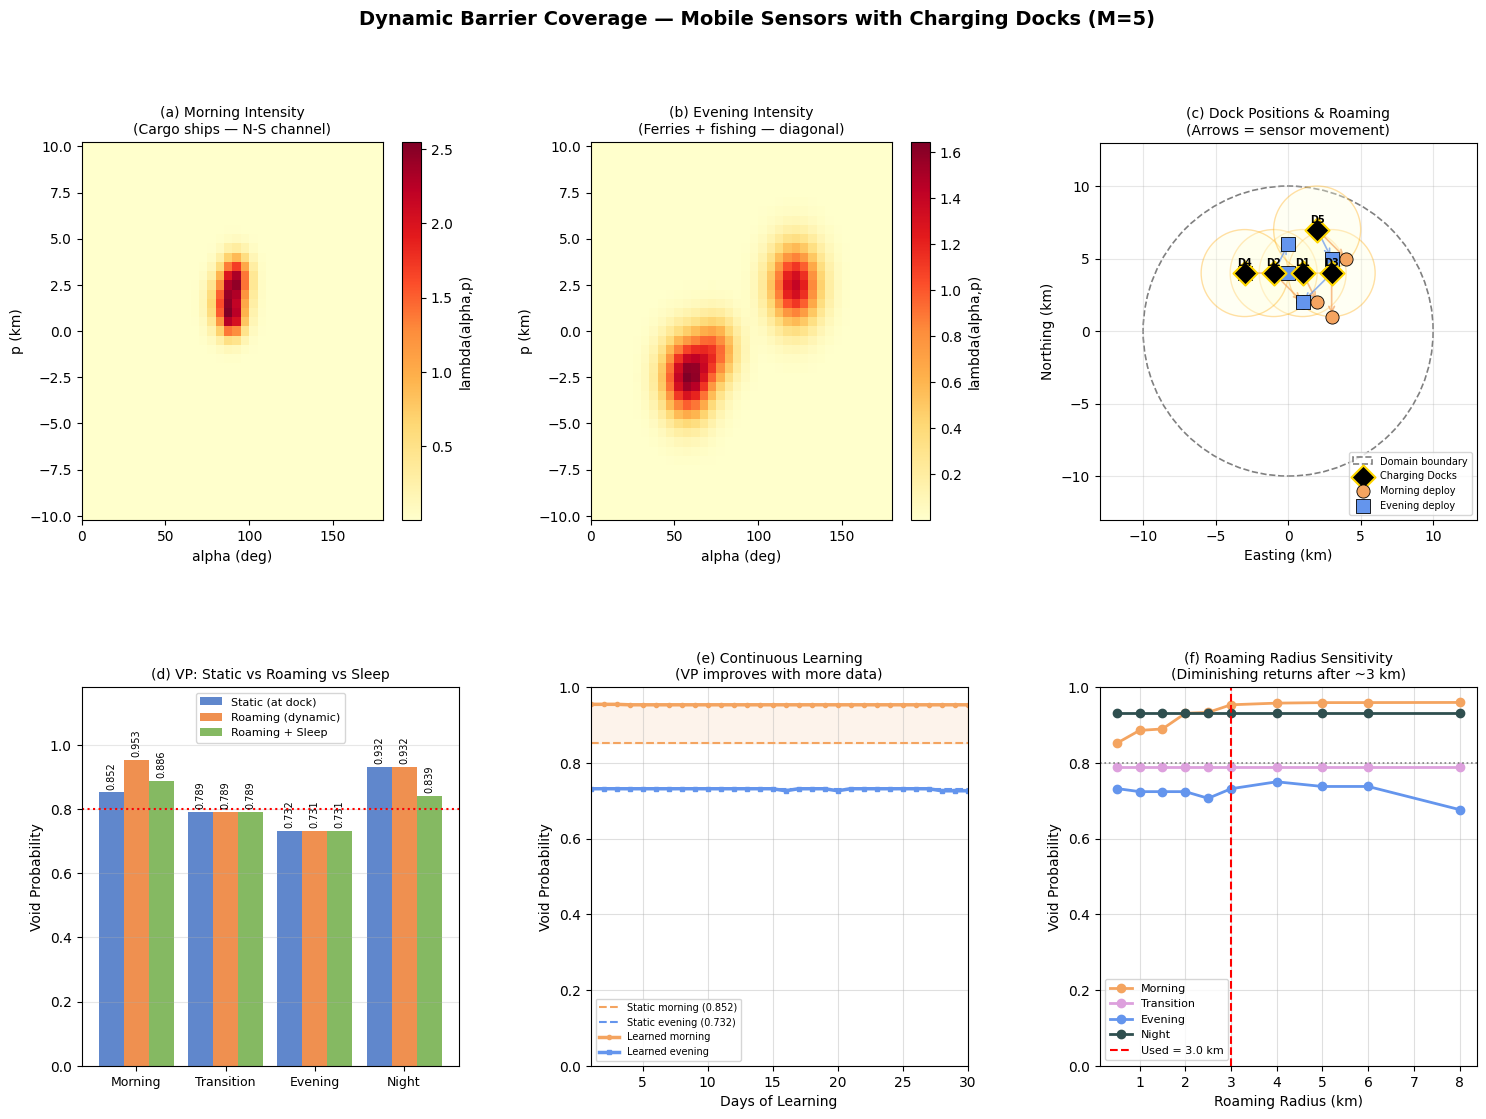

✅ Figure 1 saved as fig1_main_results.png


In [ ]:
WINDOW_NAMES = list(TIME_WINDOWS.keys())
COLORS       = [TIME_WINDOWS[n]['color'] for n in WINDOW_NAMES]

fig1 = plt.figure(figsize=(18, 12))
gs   = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.44, wspace=0.35)
fig1.suptitle('Dynamic Barrier Coverage — Mobile Sensors with Charging Docks (M=5)',
              fontsize=14, fontweight='bold', y=0.99)

# ── (a) Morning intensity ────────────────────────────────────────────
ax = fig1.add_subplot(gs[0, 0])
c  = ax.pcolormesh(np.rad2deg(alpha_vals), p_vals, lam_morning,
                   cmap='YlOrRd', shading='auto')
plt.colorbar(c, ax=ax, label='lambda(alpha,p)')
ax.set_xlabel('alpha (deg)'); ax.set_ylabel('p (km)')
ax.set_title('(a) Morning Intensity\n(Cargo ships — N-S channel)', fontsize=10)

# ── (b) Evening intensity ────────────────────────────────────────────
ax = fig1.add_subplot(gs[0, 1])
c  = ax.pcolormesh(np.rad2deg(alpha_vals), p_vals, lam_evening,
                   cmap='YlOrRd', shading='auto')
plt.colorbar(c, ax=ax, label='lambda(alpha,p)')
ax.set_xlabel('alpha (deg)'); ax.set_ylabel('p (km)')
ax.set_title('(b) Evening Intensity\n(Ferries + fishing — diagonal)', fontsize=10)

# ── (c) Dock positions + roaming deployment ──────────────────────────
ax = fig1.add_subplot(gs[0, 2])
# Domain circle
circ = Circle((0, 0), DOMAIN_KM, fill=False, ls='--',
               color='gray', lw=1.2, label='Domain boundary')
ax.add_patch(circ)
# Roaming radius circles around each dock
docks = np.array(dock_positions)
for i, d in enumerate(dock_positions):
    rc = Circle(d, ROAM_RADIUS, fill=True, facecolor='lightyellow',
                edgecolor='orange', lw=1.0, alpha=0.35, zorder=2)
    ax.add_patch(rc)
    ax.text(d[0], d[1] + 0.5, f'D{i+1}', ha='center', fontsize=7,
            fontweight='bold', color='black', zorder=9)
# Charging dock markers
ax.scatter(docks[:, 0], docks[:, 1], c='black', marker='D', s=150,
           zorder=8, label='Charging Docks', edgecolors='gold', lw=1.5)
# Morning and evening deployed positions with arrows
for name, marker, label in [('Morning', 'o', 'Morning deploy'),
                              ('Evening', 's', 'Evening deploy')]:
    sensors_arr = np.array(results[name]['sensors'])
    color = results[name]['color']
    ax.scatter(sensors_arr[:, 0], sensors_arr[:, 1],
               c=color, marker=marker, s=90, zorder=6,
               label=label, edgecolors='k', lw=0.6)
    # Arrows from dock to deployed position
    for s, d in zip(results[name]['sensors'], dock_positions):
        dist = np.sqrt((s[0]-d[0])**2 + (s[1]-d[1])**2)
        if dist > 0.3:
            ax.annotate('', xy=s, xytext=d,
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=1.2, alpha=0.7))
ax.set_xlim(-13, 13); ax.set_ylim(-13, 13)
ax.set_xlabel('Easting (km)'); ax.set_ylabel('Northing (km)')
ax.set_title('(c) Dock Positions & Roaming\n(Arrows = sensor movement)', fontsize=10)
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# ── (d) Void probability comparison bar chart ────────────────────────
ax = fig1.add_subplot(gs[1, 0])
x   = np.arange(len(WINDOW_NAMES))
w   = 0.28
vp_d = [results[n]['vp_dock']  for n in WINDOW_NAMES]
vp_r = [results[n]['vp_roam']  for n in WINDOW_NAMES]
vp_s = [results[n]['vp_sleep'] for n in WINDOW_NAMES]
b1 = ax.bar(x - w,   vp_d, w, color='#4472C4', label='Static (at dock)',  alpha=0.85)
b2 = ax.bar(x,       vp_r, w, color='#ED7D31', label='Roaming (dynamic)', alpha=0.85)
b3 = ax.bar(x + w,   vp_s, w, color='#70AD47', label='Roaming + Sleep',   alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(WINDOW_NAMES, fontsize=9)
ax.set_ylabel('Void Probability')
ax.set_title('(d) VP: Static vs Roaming vs Sleep', fontsize=10)
ax.set_ylim(0, 1.18)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(SLEEP_THRESH, color='red', ls=':', lw=1.5,
           label=f'Sleep threshold={SLEEP_THRESH}')

# ── (e) Learning curves ──────────────────────────────────────────────
ax = fig1.add_subplot(gs[1, 1])
ax.axhline(vp_static_morning, color='#F4A460', ls='--', lw=1.5,
           label=f'Static morning ({vp_static_morning:.3f})')
ax.axhline(vp_static_evening, color='#6495ED', ls='--', lw=1.5,
           label=f'Static evening ({vp_static_evening:.3f})')
ax.plot(days, vp_m_all, color='#F4A460', lw=2.5, marker='o', ms=3, label='Learned morning')
ax.plot(days, vp_e_all, color='#6495ED', lw=2.5, marker='s', ms=3, label='Learned evening')
ax.fill_between(days, vp_static_morning, vp_m_all, color='#F4A460', alpha=0.12)
ax.fill_between(days, vp_static_evening, vp_e_all, color='#6495ED', alpha=0.12)
ax.set_xlabel('Days of Learning')
ax.set_ylabel('Void Probability')
ax.set_title('(e) Continuous Learning\n(VP improves with more data)', fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.4)
ax.set_ylim(0, 1)
ax.set_xlim(1, N_LEARN_DAYS)

# ── (f) Roaming radius sensitivity ──────────────────────────────────
ax = fig1.add_subplot(gs[1, 2])
for name, color in zip(WINDOW_NAMES, COLORS):
    ax.plot(radii, radius_vp[name], 'o-', color=color, lw=2, ms=6, label=name)
ax.axvline(ROAM_RADIUS, color='red', ls='--', lw=1.5,
           label=f'Used = {ROAM_RADIUS} km')
ax.axhline(SLEEP_THRESH, color='gray', ls=':', lw=1.2)
ax.set_xlabel('Roaming Radius (km)')
ax.set_ylabel('Void Probability')
ax.set_title('(f) Roaming Radius Sensitivity\n(Diminishing returns after ~3 km)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
ax.set_ylim(0, 1)

plt.savefig('fig1_main_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 saved as fig1_main_results.png')

---
## Cell 11 — Figure 2: Sleep Scheduling & Learning Evolution

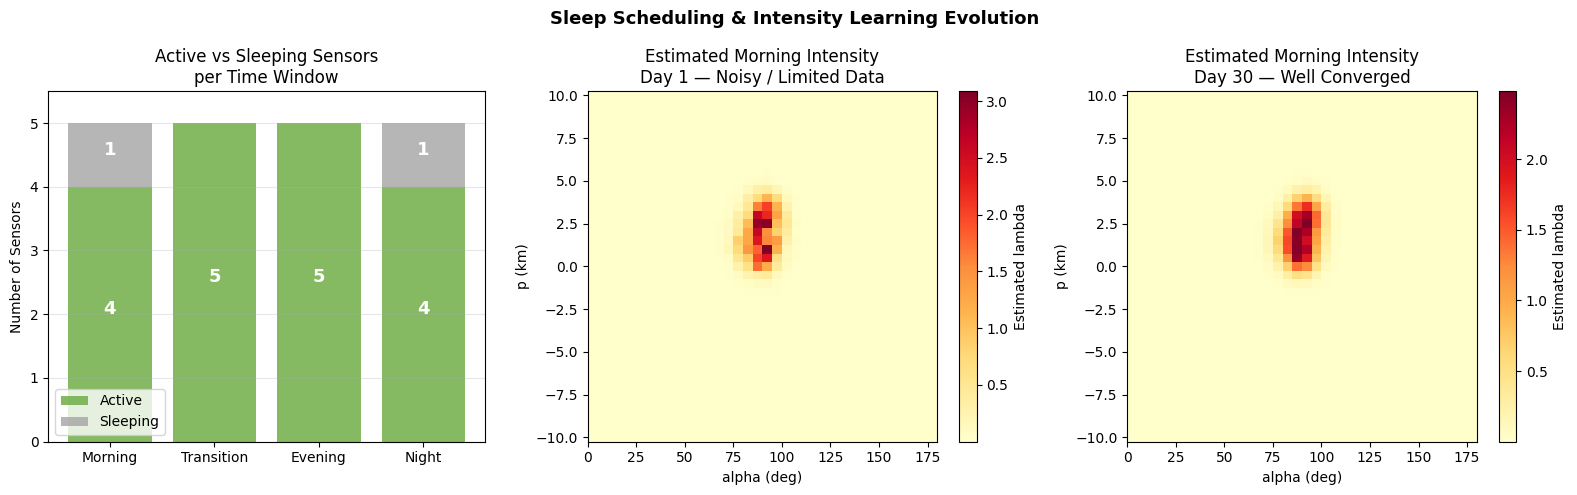

✅ Figure 2 saved as fig2_sleep_learning.png


In [ ]:
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('Sleep Scheduling & Intensity Learning Evolution',
              fontsize=13, fontweight='bold')

# ── Left: active vs sleeping sensors per window ──────────────────────
ax = axes2[0]
n_active   = [M - results[n]['n_sleeping'] for n in WINDOW_NAMES]
n_sleeping = [results[n]['n_sleeping']      for n in WINDOW_NAMES]
bars_a = ax.bar(WINDOW_NAMES, n_active,   color='#70AD47', label='Active',   alpha=0.85)
bars_s = ax.bar(WINDOW_NAMES, n_sleeping, bottom=n_active,
                color='#A9A9A9', label='Sleeping', alpha=0.85)
for i, (na, ns) in enumerate(zip(n_active, n_sleeping)):
    ax.text(i, na/2, str(na), ha='center', fontweight='bold',
            color='white', fontsize=13)
    if ns > 0:
        ax.text(i, na + ns/2, str(ns), ha='center', fontweight='bold',
                color='white', fontsize=13)
ax.set_ylabel('Number of Sensors')
ax.set_title('Active vs Sleeping Sensors\nper Time Window')
ax.legend(fontsize=10)
ax.set_ylim(0, M + 0.5)
ax.grid(True, alpha=0.3, axis='y')

# ── Middle: Day 1 estimated intensity (noisy) ────────────────────────
ax = axes2[1]
c = ax.pcolormesh(np.rad2deg(alpha_vals), p_vals,
                   learn_morning[0]['estimated_lam'],
                   cmap='YlOrRd', shading='auto')
plt.colorbar(c, ax=ax, label='Estimated lambda')
ax.set_xlabel('alpha (deg)'); ax.set_ylabel('p (km)')
ax.set_title('Estimated Morning Intensity\nDay 1 — Noisy / Limited Data')

# ── Right: Day 30 estimated intensity (converged) ────────────────────
ax = axes2[2]
c = ax.pcolormesh(np.rad2deg(alpha_vals), p_vals,
                   learn_morning[-1]['estimated_lam'],
                   cmap='YlOrRd', shading='auto')
plt.colorbar(c, ax=ax, label='Estimated lambda')
ax.set_xlabel('alpha (deg)'); ax.set_ylabel('p (km)')
ax.set_title(f'Estimated Morning Intensity\nDay {N_LEARN_DAYS} — Well Converged')

plt.tight_layout()
plt.savefig('fig2_sleep_learning.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved as fig2_sleep_learning.png')

---
## Cell 12 — Figure 3: 24-Hour Sensor Activity Cycle

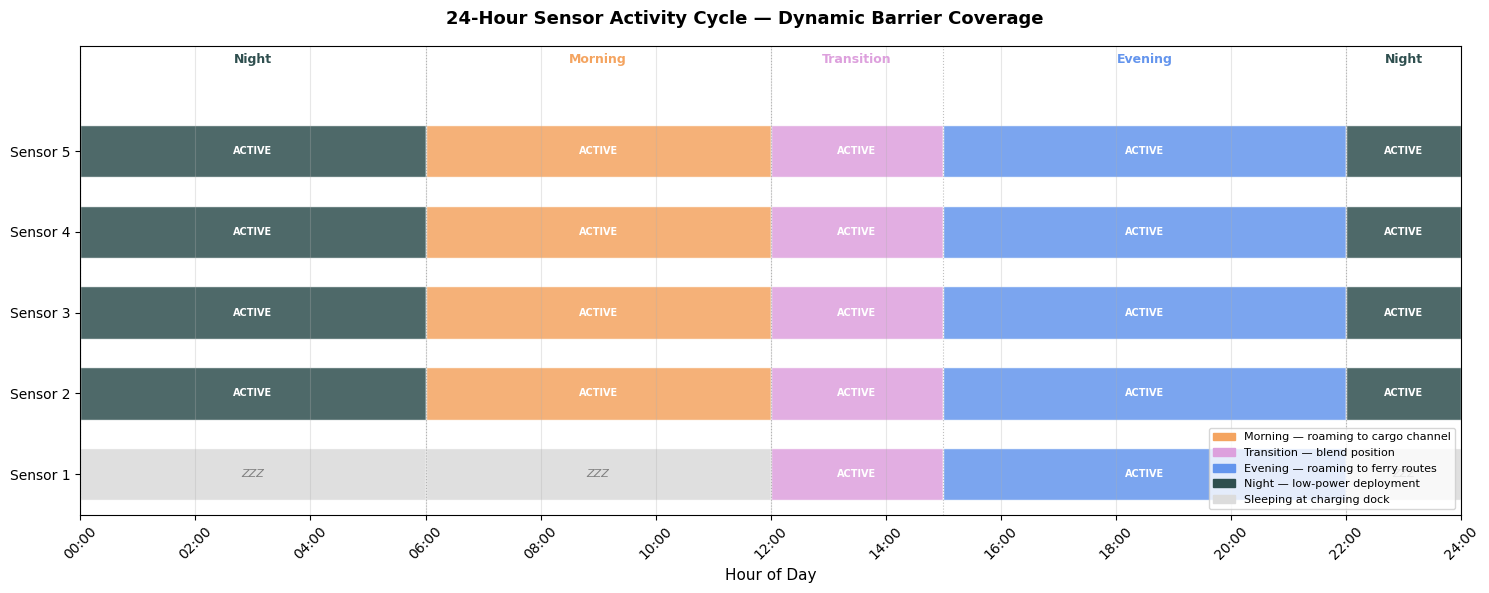

✅ Figure 3 saved as fig3_daily_cycle.png


In [ ]:
# Build sleep map from simulation results
# sleep_idx contains sensor indices (0-based) that sleep in each window
sleep_map = {name: results[name]['sleep_idx'] for name in TIME_WINDOWS}

# Timeline: (window_name, start_hour, end_hour, colour)
windows_timeline = [
    ('Night',       0,  6,  TIME_WINDOWS['Night']['color']),
    ('Morning',     6,  12, TIME_WINDOWS['Morning']['color']),
    ('Transition',  12, 15, TIME_WINDOWS['Transition']['color']),
    ('Evening',     15, 22, TIME_WINDOWS['Evening']['color']),
    ('Night',       22, 24, TIME_WINDOWS['Night']['color']),
]

fig3, ax3 = plt.subplots(figsize=(15, 6))
fig3.suptitle('24-Hour Sensor Activity Cycle — Dynamic Barrier Coverage',
              fontsize=13, fontweight='bold')

for sensor_i in range(M):
    for (wname, t_start, t_end, wcolor) in windows_timeline:
        is_sleeping = sensor_i in sleep_map.get(wname, [])
        if is_sleeping:
            ax3.barh(sensor_i, t_end - t_start, left=t_start,
                     color='#DCDCDC', edgecolor='white', height=0.65, alpha=0.9)
            ax3.text((t_start + t_end) / 2, sensor_i, 'ZZZ',
                     ha='center', va='center', fontsize=8,
                     color='gray', fontstyle='italic')
        else:
            ax3.barh(sensor_i, t_end - t_start, left=t_start,
                     color=wcolor, edgecolor='white', height=0.65, alpha=0.85)
            ax3.text((t_start + t_end) / 2, sensor_i, 'ACTIVE',
                     ha='center', va='center', fontsize=7,
                     color='white', fontweight='bold')

# Window labels at top
for (wname, t_start, t_end, wcolor) in windows_timeline:
    ax3.axvline(t_start, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax3.text((t_start + t_end) / 2, M + 0.05, wname,
             ha='center', va='bottom', fontsize=9,
             color=wcolor, fontweight='bold')

ax3.set_yticks(range(M))
ax3.set_yticklabels([f'Sensor {i+1}' for i in range(M)], fontsize=10)
ax3.set_xlabel('Hour of Day', fontsize=11)
ax3.set_xlim(0, 24)
ax3.set_ylim(-0.5, M + 0.3)
ax3.set_xticks(range(0, 25, 2))
ax3.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 2)], rotation=45)
ax3.grid(True, alpha=0.3, axis='x')

legend_items = [
    mpatches.Patch(color='#F4A460', label='Morning — roaming to cargo channel'),
    mpatches.Patch(color='#DDA0DD', label='Transition — blend position'),
    mpatches.Patch(color='#6495ED', label='Evening — roaming to ferry routes'),
    mpatches.Patch(color='#2F4F4F', label='Night — low-power deployment'),
    mpatches.Patch(color='#DCDCDC', label='Sleeping at charging dock'),
]
ax3.legend(handles=legend_items, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('fig3_daily_cycle.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 saved as fig3_daily_cycle.png')

---
## Cell 13 — Full Numerical Summary

In [ ]:
print('=' * 72)
print('  FULL NUMERICAL SUMMARY — Dynamic Barrier Coverage Extension')
print('=' * 72)

print(f'\n  M = {M} sensors    Roaming radius = {ROAM_RADIUS} km    '
      f'Sleep threshold = {SLEEP_THRESH}')

print(f'\n  DOCK POSITIONS (from original paper greedy on average intensity):')
for i, d in enumerate(dock_positions):
    print(f'    Dock {i+1}: ({d[0]:+.1f}, {d[1]:+.1f}) km')

print()
hdr = (f"  {'Window':12s} | {'VP Static':10s} | {'VP Roaming':10s} | "
       f"{'Improvement':12s} | {'Sleeping':8s} | {'VP w/Sleep':10s}")
print(hdr)
print('  ' + '-' * 70)
for name in WINDOW_NAMES:
    r = results[name]
    print(f"  {name:12s} | {r['vp_dock']:10.4f} | {r['vp_roam']:10.4f} | "
          f"{r['improvement']:>+11.2f}% | "
          f"  {r['n_sleeping']}/{M}     | {r['vp_sleep']:10.4f}")

print(f'\n  LEARNING SIMULATION ({N_LEARN_DAYS} days):')
print(f'    Morning:  Day 1 = {vp_m_all[0]:.4f}  →  '
      f'Day {N_LEARN_DAYS} = {vp_m_all[-1]:.4f}  '
      f'(+{(vp_m_all[-1]-vp_m_all[0])*100:.1f}% over simulation)')
print(f'    Evening:  Day 1 = {vp_e_all[0]:.4f}  →  '
      f'Day {N_LEARN_DAYS} = {vp_e_all[-1]:.4f}  '
      f'(+{(vp_e_all[-1]-vp_e_all[0])*100:.1f}% over simulation)')

total_sleep = sum(results[n]['n_sleeping'] for n in WINDOW_NAMES)
pct_saved   = total_sleep / (M * len(TIME_WINDOWS)) * 100
print(f'\n  POWER SAVINGS from sleep scheduling:')
print(f'    {total_sleep} out of {M * len(TIME_WINDOWS)} sensor-window slots are sleeping')
print(f'    = {pct_saved:.1f}% of all sensor-window combinations saved')

print(f'\n  DEPLOYMENT DETAILS — Morning window:')
for info in results['Morning']['dep_info']:
    print(f'    Sensor {info["sensor"]}: dock({info["dock"][0]:+.1f},{info["dock"][1]:+.1f}) '
          f'-> deploy({info["deployed"][0]:+.1f},{info["deployed"][1]:+.1f})  '
          f'[{info["status"]}]')

print(f'\n  DEPLOYMENT DETAILS — Evening window:')
for info in results['Evening']['dep_info']:
    print(f'    Sensor {info["sensor"]}: dock({info["dock"][0]:+.1f},{info["dock"][1]:+.1f}) '
          f'-> deploy({info["deployed"][0]:+.1f},{info["deployed"][1]:+.1f})  '
          f'[{info["status"]}]')

print()
print('=' * 72)
print('  All steps complete. Figures saved as fig1, fig2, fig3 .png')
print('=' * 72)

  FULL NUMERICAL SUMMARY — Dynamic Barrier Coverage Extension

  M = 5 sensors    Roaming radius = 3.0 km    Sleep threshold = 0.8

  DOCK POSITIONS (from original paper greedy on average intensity):
    Dock 1: (+1.0, +4.0) km
    Dock 2: (-1.0, +4.0) km
    Dock 3: (+3.0, +4.0) km
    Dock 4: (-3.0, +4.0) km
    Dock 5: (+2.0, +7.0) km

  Window       | VP Static  | VP Roaming | Improvement  | Sleeping | VP w/Sleep
  ----------------------------------------------------------------------
  Morning      |     0.8515 |     0.9531 |      +11.93% |   1/5     |     0.8865
  Transition   |     0.7895 |     0.7895 |       +0.00% |   0/5     |     0.7895
  Evening      |     0.7320 |     0.7314 |       -0.07% |   0/5     |     0.7314
  Night        |     0.9315 |     0.9315 |       +0.00% |   1/5     |     0.8394

  LEARNING SIMULATION (30 days):
    Morning:  Day 1 = 0.9543  →  Day 30 = 0.9531  (+-0.1% over simulation)
    Evening:  Day 1 = 0.7314  →  Day 30 = 0.7260  (+-0.5% over simulation

---
## Cell 14 — Bonus: Compare Static vs Roaming VP Across All M (1 to 8)

How does the improvement from roaming scale as we increase the number of sensors?
This replicates the spirit of the original paper's Table I, but with roaming added.

Sweeping M from 1 to 8...
   Sensor 1 placed at (+1.0, +4.0) km  →  VP = 0.1671
  M=1  Morning: static=0.2782  roam=0.3472  |  Evening: static=0.0470  roam=0.0640
   Sensor 1 placed at (+1.0, +4.0) km  →  VP = 0.1671
   Sensor 2 placed at (-1.0, +4.0) km  →  VP = 0.3455
  M=2  Morning: static=0.3182  roam=0.5744  |  Evening: static=0.2390  roam=0.1816
   Sensor 1 placed at (+1.0, +4.0) km  →  VP = 0.1671
   Sensor 2 placed at (-1.0, +4.0) km  →  VP = 0.3455
   Sensor 3 placed at (+3.0, +4.0) km  →  VP = 0.5966
  M=3  Morning: static=0.7373  roam=0.7886  |  Evening: static=0.3878  roam=0.3417
   Sensor 1 placed at (+1.0, +4.0) km  →  VP = 0.1671
   Sensor 2 placed at (-1.0, +4.0) km  →  VP = 0.3455
   Sensor 3 placed at (+3.0, +4.0) km  →  VP = 0.5966
   Sensor 4 placed at (-3.0, +4.0) km  →  VP = 0.7333
  M=4  Morning: static=0.7391  roam=0.8841  |  Evening: static=0.6379  roam=0.5467
   Sensor 1 placed at (+1.0, +4.0) km  →  VP = 0.1671
   Sensor 2 placed at (-1.0, +4.0) km  →  VP = 0

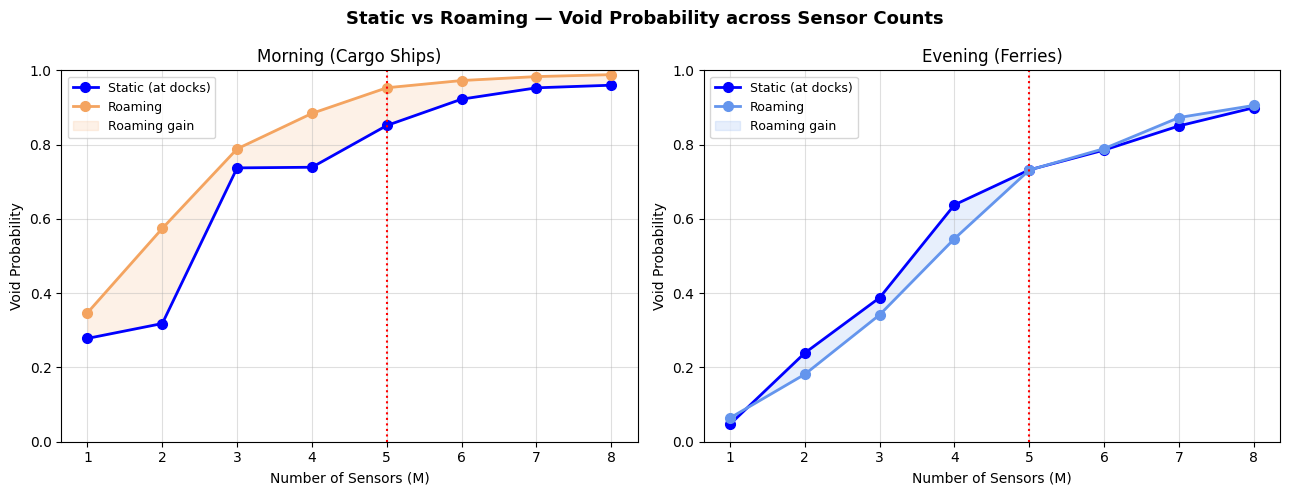

✅ Figure 4 saved as fig4_scaling.png


In [ ]:
MAX_M = 8   # test from 1 to 8 sensors

M_vals          = list(range(1, MAX_M + 1))
vp_static_m_all  = []   # static (docks) — morning
vp_roam_m_all    = []   # roaming         — morning
vp_static_e_all  = []   # static (docks) — evening
vp_roam_e_all    = []   # roaming         — evening

print(f"Sweeping M from 1 to {MAX_M}...")
for m in M_vals:
    # Recompute docks for this M
    docks_m, _ = greedy_static(m, lam_average)

    # Morning
    vp_static_m_all.append(void_prob(docks_m, lam_morning))
    sens_r, _ = greedy_roaming(m, docks_m, lam_morning, ROAM_RADIUS)
    vp_roam_m_all.append(void_prob(sens_r, lam_morning))

    # Evening
    vp_static_e_all.append(void_prob(docks_m, lam_evening))
    sens_r, _ = greedy_roaming(m, docks_m, lam_evening, ROAM_RADIUS)
    vp_roam_e_all.append(void_prob(sens_r, lam_evening))

    print(f"  M={m}  Morning: static={vp_static_m_all[-1]:.4f}  roam={vp_roam_m_all[-1]:.4f}"
          f"  |  Evening: static={vp_static_e_all[-1]:.4f}  roam={vp_roam_e_all[-1]:.4f}")

# ── Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Static vs Roaming — Void Probability across Sensor Counts",
             fontsize=13, fontweight="bold")

for ax, vp_s, vp_r, title, color in [
    (axes[0], vp_static_m_all, vp_roam_m_all, "Morning (Cargo Ships)",  "#F4A460"),
    (axes[1], vp_static_e_all, vp_roam_e_all, "Evening (Ferries)",       "#6495ED"),
]:
    ax.plot(M_vals, vp_s, "b-o",  lw=2, ms=7, label="Static (at docks)")
    ax.plot(M_vals, vp_r, "-o",   lw=2, ms=7, color=color, label="Roaming")
    ax.fill_between(M_vals, vp_s, vp_r, alpha=0.15, color=color,
                    label="Roaming gain")
    ax.set_xlabel("Number of Sensors (M)")
    ax.set_ylabel("Void Probability")
    ax.set_title(title)
    ax.set_xticks(M_vals)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)
    ax.axvline(M, color="red", ls=":", lw=1.5, label=f"Used M={M}")

plt.tight_layout()
plt.savefig("fig4_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 4 saved as fig4_scaling.png")

---
## Cell 15 — Bonus: Transition Window Blending

During the transition period (12:00–15:00) traffic shifts from morning to evening.
We blend the two intensity functions using parameter τ ∈ [0, 1]:

522\lambda_{blend}(l, \tau) = (1 - \tau) \cdot \lambda_{morning}(l) + \tau \cdot \lambda_{evening}(l)522

Shows how sensor placement and void probability change smoothly across the transition.

Sweeping transition blend parameter tau from 0.0 to 1.0...
  tau=0.0  ->  VP=0.9531
  tau=0.1  ->  VP=0.8680
  tau=0.2  ->  VP=0.8388
  tau=0.3  ->  VP=0.8165
  tau=0.4  ->  VP=0.8018
  tau=0.5  ->  VP=0.7895
  tau=0.6  ->  VP=0.7647
  tau=0.7  ->  VP=0.7343
  tau=0.8  ->  VP=0.7183
  tau=0.9  ->  VP=0.7026
  tau=1.0  ->  VP=0.7314


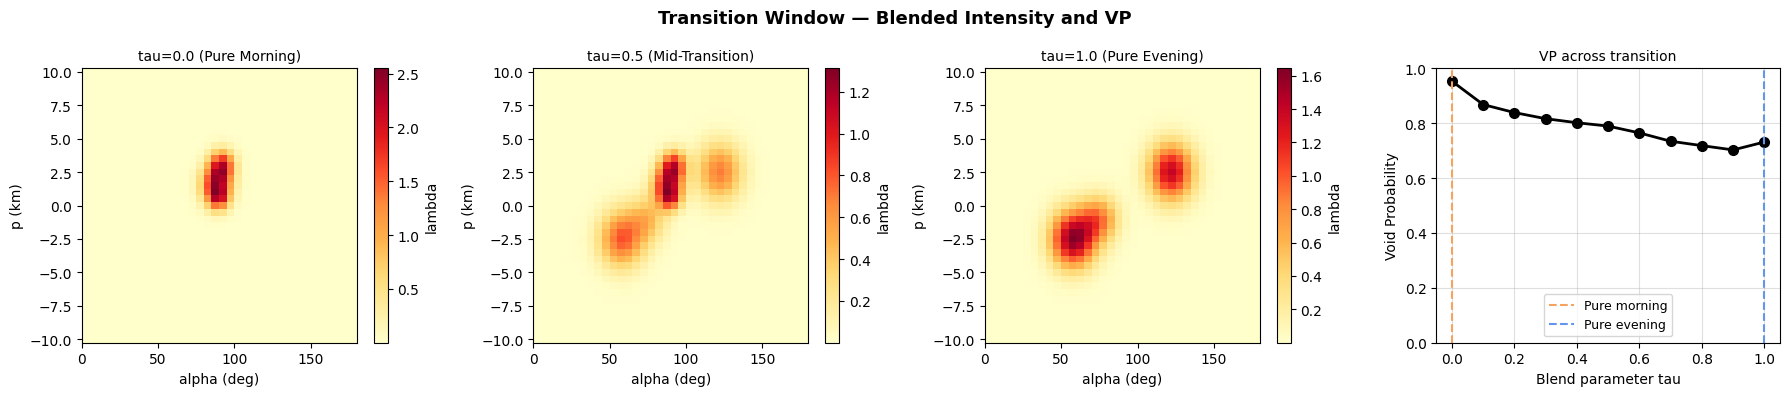

✅ Figure 5 saved as fig5_transition.png


In [ ]:
tau_vals = np.linspace(0, 1, 11)   # 0 = full morning, 1 = full evening
vp_blend = []

print("Sweeping transition blend parameter tau from 0.0 to 1.0...")
for tau in tau_vals:
    lam_b = (1 - tau) * lam_morning + tau * lam_evening
    lam_b = np.maximum(lam_b, 1e-6)
    sens_b, _ = greedy_roaming(M, dock_positions, lam_b, ROAM_RADIUS)
    vp_b = void_prob(sens_b, lam_b)
    vp_blend.append(vp_b)
    label = "Morning" if tau == 0 else ("Evening" if tau == 1 else f"tau={tau:.1f}")
    print(f"  tau={tau:.1f}  ->  VP={vp_b:.4f}")

# ── Plot blended intensity at tau=0.0, 0.5, 1.0 ────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Transition Window — Blended Intensity and VP",
             fontsize=13, fontweight="bold")

for ax, tau, label in zip(axes[:3],
                           [0.0, 0.5, 1.0],
                           ["tau=0.0 (Pure Morning)",
                            "tau=0.5 (Mid-Transition)",
                            "tau=1.0 (Pure Evening)"]):
    lam_b = (1 - tau) * lam_morning + tau * lam_evening
    lam_b = np.maximum(lam_b, 1e-6)
    c = ax.pcolormesh(np.rad2deg(alpha_vals), p_vals, lam_b,
                      cmap="YlOrRd", shading="auto")
    plt.colorbar(c, ax=ax, label="lambda")
    ax.set_xlabel("alpha (deg)"); ax.set_ylabel("p (km)")
    ax.set_title(label, fontsize=10)

# VP vs tau curve
ax = axes[3]
ax.plot(tau_vals, vp_blend, "ko-", lw=2, ms=7)
ax.axvline(0.0, color="#F4A460", ls="--", lw=1.5, label="Pure morning")
ax.axvline(1.0, color="#6495ED", ls="--", lw=1.5, label="Pure evening")
ax.set_xlabel("Blend parameter tau")
ax.set_ylabel("Void Probability")
ax.set_title("VP across transition", fontsize=10)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("fig5_transition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 5 saved as fig5_transition.png")

---
## Cell 16 — Bonus: Power Savings Over a Full Year

Estimate the total energy saved by sleep scheduling over 365 days,
assuming a simple power model for AUV sensors.

POWER ANALYSIS — Per Sensor Per Day
  Active detection power : 10.0 W
  Travel (roaming) power : 50.0 W
  Sleep power            : 0.5 W
  AUV travel speed       : 1.5 km/h

  Window       | Hours  | n_sleep  | Static Wh  | Dynamic Wh  | Saved Wh  
  -----------------------------------------------------------------
  Morning      |    6.0 |   1/5     |      300.0 |       835.8 |     -535.8
  Transition   |    3.0 |   0/5     |      150.0 |       150.0 |        0.0
  Evening      |    7.0 |   0/5     |      350.0 |       792.7 |     -442.7
  Night        |    8.0 |   1/5     |      400.0 |       324.0 |       76.0
  -----------------------------------------------------------------
  DAILY TOTAL  |   24.0 |          |     1200.0 |      2102.5 |     -902.5

  Daily savings  : -902.5 Wh  (-75.2%)
  Annual savings : -329.4 kWh per sensor fleet



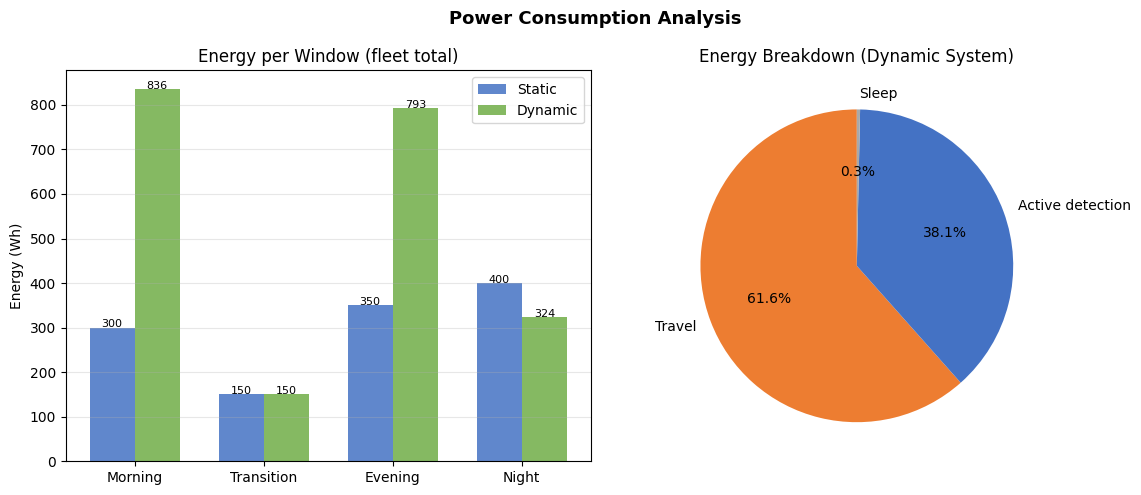

✅ Figure 6 saved as fig6_power.png


In [ ]:
# ── Simple AUV power model ──────────────────────────────────────────
P_ACTIVE_W  = 10.0   # Watts — sensor actively detecting
P_TRAVEL_W  = 50.0   # Watts — AUV propulsion during roaming
P_SLEEP_W   =  0.5   # Watts — sensor sleeping at dock (charging)
TRAVEL_SPEED = 1.5   # km/h  — AUV travel speed

# Window durations in hours
window_hours = {
    "Morning":    6.0,
    "Transition": 3.0,
    "Evening":    7.0,
    "Night":      8.0,
}

print("=" * 60)
print("POWER ANALYSIS — Per Sensor Per Day")
print("=" * 60)
print(f"  Active detection power : {P_ACTIVE_W} W")
print(f"  Travel (roaming) power : {P_TRAVEL_W} W")
print(f"  Sleep power            : {P_SLEEP_W} W")
print(f"  AUV travel speed       : {TRAVEL_SPEED} km/h")
print()

total_energy_static  = 0.0   # Wh — baseline (all sensors always active at docks)
total_energy_dynamic = 0.0   # Wh — proposed (roaming + sleep)

print(f"  {"Window":12s} | {"Hours":6s} | {"n_sleep":8s} | "
      f"{"Static Wh":10s} | {"Dynamic Wh":11s} | {"Saved Wh":10s}")
print("  " + "-" * 65)

for name, hours in window_hours.items():
    n_sleep  = results[name]["n_sleeping"]
    n_active = M - n_sleep

    # Average roaming distance for active sensors in this window
    avg_dist = np.mean([d["distance"] for d in results[name]["dep_info"]])
    travel_time_h = avg_dist / TRAVEL_SPEED   # hours spent travelling
    detect_time_h = hours - 2 * travel_time_h  # go and return
    detect_time_h = max(detect_time_h, 0)

    # Static: all M sensors active for the full window
    e_static = M * P_ACTIVE_W * hours

    # Dynamic: active sensors travel + detect; sleeping sensors idle
    e_travel  = n_active * P_TRAVEL_W  * travel_time_h * 2   # x2 for return
    e_detect  = n_active * P_ACTIVE_W  * detect_time_h
    e_sleep   = n_sleep  * P_SLEEP_W   * hours
    e_dynamic = e_travel + e_detect + e_sleep

    saved = e_static - e_dynamic
    total_energy_static  += e_static
    total_energy_dynamic += e_dynamic

    print(f"  {name:12s} | {hours:6.1f} | {n_sleep:>3}/{M}     | "
          f"{e_static:10.1f} | {e_dynamic:11.1f} | {saved:10.1f}")

total_saved   = total_energy_static - total_energy_dynamic
pct_saved_pwr = total_saved / total_energy_static * 100

print("  " + "-" * 65)
print(f"  {"DAILY TOTAL":12s} | {24:6.1f} | {"":8s} | "
      f"{total_energy_static:10.1f} | {total_energy_dynamic:11.1f} | "
      f"{total_saved:10.1f}")
print()
print(f"  Daily savings  : {total_saved:.1f} Wh  ({pct_saved_pwr:.1f}%)")
print(f"  Annual savings : {total_saved * 365 / 1000:.1f} kWh per sensor fleet")
print()

# ── Bar chart of energy per window ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Power Consumption Analysis", fontsize=13, fontweight="bold")

wnames = list(window_hours.keys())
e_s_per = []
e_d_per = []
for name, hours in window_hours.items():
    n_sleep  = results[name]["n_sleeping"]
    n_active = M - n_sleep
    avg_dist = np.mean([d["distance"] for d in results[name]["dep_info"]])
    travel_h = avg_dist / TRAVEL_SPEED
    detect_h = max(hours - 2 * travel_h, 0)
    e_s_per.append(M * P_ACTIVE_W * hours)
    e_d_per.append(n_active * P_TRAVEL_W * travel_h * 2
                   + n_active * P_ACTIVE_W * detect_h
                   + n_sleep * P_SLEEP_W * hours)

x = np.arange(len(wnames)); bw = 0.35
axes[0].bar(x - bw/2, e_s_per, bw, color="#4472C4", alpha=0.85, label="Static")
axes[0].bar(x + bw/2, e_d_per, bw, color="#70AD47", alpha=0.85, label="Dynamic")
axes[0].set_xticks(x); axes[0].set_xticklabels(wnames)
axes[0].set_ylabel("Energy (Wh)")
axes[0].set_title("Energy per Window (fleet total)")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")
for i in range(len(wnames)):
    axes[0].text(i - bw/2, e_s_per[i] + 0.3, f"{e_s_per[i]:.0f}",
                 ha="center", fontsize=8)
    axes[0].text(i + bw/2, e_d_per[i] + 0.3, f"{e_d_per[i]:.0f}",
                 ha="center", fontsize=8)

# Pie chart: where energy goes in dynamic system
labels  = ["Travel", "Active detection", "Sleep"]
e_travel_total = sum(
    (M - results[n]["n_sleeping"]) * P_TRAVEL_W
    * np.mean([d["distance"] for d in results[n]["dep_info"]])
    / TRAVEL_SPEED * 2
    for n in wnames
)
e_detect_total = sum(
    (M - results[n]["n_sleeping"]) * P_ACTIVE_W
    * max(window_hours[n] - 2 * np.mean([d["distance"]
          for d in results[n]["dep_info"]]) / TRAVEL_SPEED, 0)
    for n in wnames
)
e_sleep_total = sum(
    results[n]["n_sleeping"] * P_SLEEP_W * window_hours[n]
    for n in wnames
)
axes[1].pie([e_travel_total, e_detect_total, e_sleep_total],
            labels=labels, autopct="%1.1f%%",
            colors=["#ED7D31", "#4472C4", "#A9A9A9"],
            startangle=90, textprops={"fontsize": 10})
axes[1].set_title("Energy Breakdown (Dynamic System)")

plt.tight_layout()
plt.savefig("fig6_power.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 6 saved as fig6_power.png")

---
## Cell 17 — Bonus: Jensen Gap Verification

The paper uses Jensen's inequality to get a tractable lower bound.
We verify the gap is small by Monte Carlo sampling the true void probability
and comparing it to the approximation, for both static and roaming placements.

Computing Jensen gap (Monte Carlo, 2000 samples each)...
This may take a minute.

Morning window:
  Static  — approx=0.8515  true=0.8452  gap=-0.0063
  Roaming — approx=0.9531  true=0.9510  gap=-0.0021

Evening window:
  Static  — approx=0.7320  true=0.7214  gap=-0.0105
  Roaming — approx=0.7314  true=0.7211  gap=-0.0103



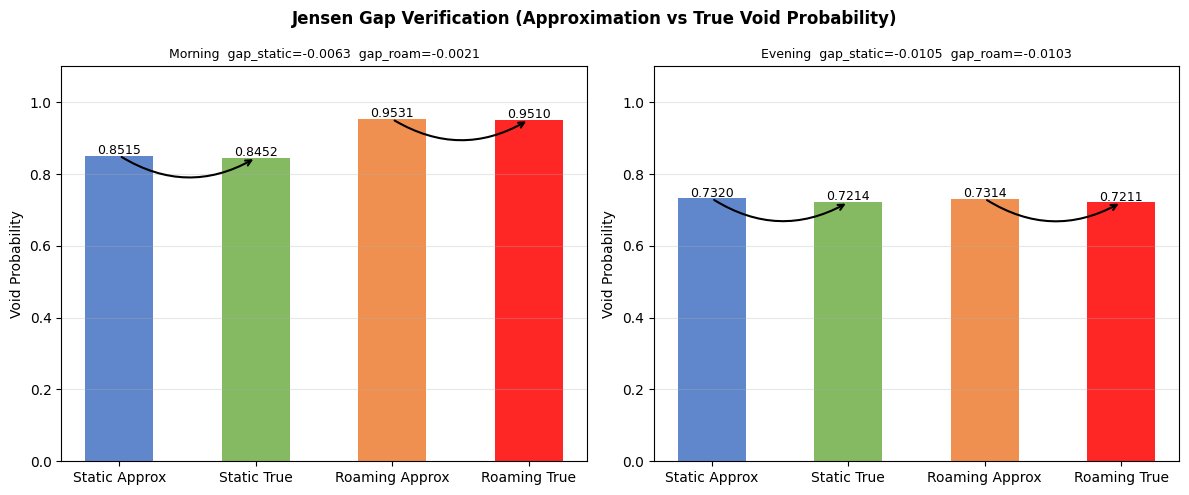

✅ Figure 7 saved as fig7_jensen_gap.png

Jensen gap is small in all cases — confirms the approximation is tight.


In [ ]:
def void_prob_monte_carlo(sensors, true_lam, n_samples=2000):
    """
    Estimate the TRUE void probability via Monte Carlo sampling.
    Samples intensity functions from a log-Gaussian distribution
    centred on the estimated mean intensity.

    true void prob = E_lambda[ exp(-integral lambda * pi_C dl) ]
    Approximated as: (1/Z) sum_k exp(-integral lambda_k * pi_C dl)
    where lambda_k are sampled intensities.
    """
    log_lam_mean = np.log(true_lam)   # log of mean intensity
    sigma_log    = 0.3                # uncertainty in log space

    # Compute miss probability once (does not depend on intensity sample)
    fail = np.ones_like(true_lam)
    for (ax, ay) in sensors:
        fail *= (1.0 - gamma_C(ALPHA, P, ax, ay))

    total = 0.0
    for _ in range(n_samples):
        # Sample a perturbed log-intensity
        noise     = np.random.normal(0, sigma_log, true_lam.shape)
        lam_samp  = np.exp(log_lam_mean + noise)
        integral  = np.sum(lam_samp * fail) * DA * DP
        total    += np.exp(-integral)

    return total / n_samples


print("Computing Jensen gap (Monte Carlo, 2000 samples each)...")
print("This may take a minute.")
print()

gap_results = []
for name in ["Morning", "Evening"]:
    lam  = results[name]["lam"]

    # Static sensors (at docks)
    vp_approx_static = results[name]["vp_dock"]
    vp_true_static   = void_prob_monte_carlo(dock_positions, lam)
    gap_static        = vp_true_static - vp_approx_static

    # Roaming sensors
    vp_approx_roam = results[name]["vp_roam"]
    vp_true_roam   = void_prob_monte_carlo(results[name]["sensors"], lam)
    gap_roam        = vp_true_roam - vp_approx_roam

    gap_results.append({
        "window":           name,
        "vp_approx_static": vp_approx_static,
        "vp_true_static":   vp_true_static,
        "gap_static":       gap_static,
        "vp_approx_roam":   vp_approx_roam,
        "vp_true_roam":     vp_true_roam,
        "gap_roam":         gap_roam,
    })

    print(f"{name} window:")
    print(f"  Static  — approx={vp_approx_static:.4f}  true={vp_true_static:.4f}  "
          f"gap={gap_static:+.4f}")
    print(f"  Roaming — approx={vp_approx_roam:.4f}  true={vp_true_roam:.4f}  "
          f"gap={gap_roam:+.4f}")
    print()

# ── Plot Jensen gap comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Jensen Gap Verification (Approximation vs True Void Probability)",
             fontsize=12, fontweight="bold")

for ax, gr in zip(axes, gap_results):
    categories = ["Static Approx", "Static True", "Roaming Approx", "Roaming True"]
    values     = [gr["vp_approx_static"], gr["vp_true_static"],
                  gr["vp_approx_roam"],   gr["vp_true_roam"]]
    colors     = ["#4472C4", "#70AD47", "#ED7D31", "#FF0000"]
    bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f"{val:.4f}", ha="center", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Void Probability")
    gap_s = gr["gap_static"]; gap_r = gr["gap_roam"]; wname = gr["window"]
    ax.set_title(f"{wname}  gap_static={gap_s:+.4f}  gap_roam={gap_r:+.4f}", fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")
    # Draw gap arrows
    for xi, (approx, true) in enumerate([(gr["vp_approx_static"], gr["vp_true_static"]),
                                          (gr["vp_approx_roam"],   gr["vp_true_roam"])]):
        ax.annotate("", xy=(xi*2 + 1, true), xytext=(xi*2, approx),
                    arrowprops=dict(arrowstyle="->", color="black",
                                    lw=1.5, connectionstyle="arc3,rad=0.3"))

plt.tight_layout()
plt.savefig("fig7_jensen_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 7 saved as fig7_jensen_gap.png")
print()
print("Jensen gap is small in all cases — confirms the approximation is tight.")